In [47]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

from src.models.base_models import get_base_lasso, get_base_xgboost
from src.pipeline import build_base_pipeline
from src.plots import plot_model_comparison
%load_ext autoreload
%autoreload 2

from src.utils import DEV_SET_CLEAN_PATH, COLS, TARGET
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
# cargamos predicciones de modelos base para comparar
df_base_preds = pd.read_csv("../predictions/base_models.csv")

y_pred_dummy = df_base_preds['Dummy'].values
models_predictions = {
    'model': ['Dummy', 'Lasso', 'XGBoost'], # no nos interesa learning tree realmente
    'y_pred': [y_pred_dummy, df_base_preds['Lasso'].values, df_base_preds['XGBoost'].values],
    'y_test': df_base_preds['y_test'].values,
}

In [49]:
# cargamos dataset
df = pd.read_csv("../" + DEV_SET_CLEAN_PATH)

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Función para comparar el impacto de feature engineering:

In [50]:
def plot_feature_engineering_impact(df_train, df_test, feature_engineer_func):
    X_train_eng = feature_engineer_func(df_train)
    X_test_eng = feature_engineer_func(df_test)

    # pipeline básico de preprocesado, igual que en 02-base_models.ipynb
    numeric_cols = X_train_eng.select_dtypes(include=["number"]).columns.tolist()
    categorical_cols = X_train_eng.select_dtypes(include=["object", "bool"]).columns.tolist()

    base_preprocessor = build_base_pipeline(numeric_cols, categorical_cols)

    lasso_eng = get_base_lasso(base_preprocessor)
    lasso_eng.fit(X_train_eng, y_train)
    lasso_eng_pred = lasso_eng.predict(X_test_eng)

    xgboost_eng = get_base_xgboost(base_preprocessor)
    xgboost_eng.fit(X_train_eng, y_train)
    xgboost_eng_pred = xgboost_eng.predict(X_test_eng)

    model_predictions_eng = models_predictions.copy()
    model_predictions_eng['y_pred_processed'] = [y_pred_dummy, lasso_eng_pred, xgboost_eng_pred]
    model_predictions_eng['y_test_processed'] = y_test
    plot_model_comparison(model_predictions_eng)

### Idea 1: Score de amenities
Una feature que sume la cantidad de amenities. Cuantos más amenities, mejor

In [51]:
AMENITIES = [COLS.AMOBLADO, COLS.GIMNASIO, COLS.LAUNDRY, COLS.CALEFACCION, COLS.AIRE, COLS.SEGURIDAD, COLS.PILETA, COLS.TENNIS, COLS.RECEPCION, COLS.BUSINESS, COLS.ESTACIONAMIENTO, "SUM", COLS.JACUZZI]

def add_amenities_score(df_in):
    df_out = df_in.copy()
    df_out['amenities_score'] = df_out[AMENITIES].sum(axis=1)
    return df_out

df_amenities = add_amenities_score(df)
df_amenities.head()

,id_grid,STotalM2,SConstrM2,Dormitorios,Banos,Ambientes,Amoblado,Antiguedad,BusinessCenter,Gimnasio,...,ITE_ADD_STATE_NAME,ITE_ADD_NEIGHBORHOOD_NAME,ITE_TIPO_PROD,LONGITUDE,LATITUDE,precio_pesos_constantes,year,SUM,mes_listing,amenities_score
0,59362,39.0,36.0,1.0,1.0,2.0,False,0.0,False,False,...,Bs.As. G.B.A. Oeste,Caseros,N,-58.566145,-34.599299,6.279294e+03,2022,False,8,0
1,68287,47.0,40.0,1.0,1.0,2.0,False,7.0,False,False,...,Capital Federal,Núñez,U,-58.473708,-34.551759,1.092339e+04,2021,False,4,1
2,59774,128.0,63.0,1.0,1.0,3.0,False,40.0,False,False,...,Capital Federal,NaN,U,-58.385136,-34.599685,1.081992e+04,2021,False,9,2
3,62402,436.0,436.0,2.0,3.0,8.0,NaN,50.0,NaN,False,...,Capital Federal,Recoleta,U,-58.393617,-34.585162,1.230069e+05,2022,NaN,11,2
4,57804,300.0,300.0,2.0,4.0,6.0,False,0.0,False,False,...,Capital Federal,Monserrat,U,-58.376592,-34.610603,7.714647e+06,2021,False,4,0


### Idea 2: metros por ambientes
Ambientes más espaciosos pueden levantar el precio

In [52]:
def add_room_density(df_in):
    df_out = df_in.copy()
    ambientes_safe = df_out[COLS.AMBIENTES].replace(0, np.nan)
    df_out['room_size'] = df_out[COLS.SUP_CONSTR] / ambientes_safe
    return df_out

df_densidad = add_room_density(df)
df_densidad.head()


,id_grid,STotalM2,SConstrM2,Dormitorios,Banos,Ambientes,Amoblado,Antiguedad,BusinessCenter,Gimnasio,...,ITE_ADD_STATE_NAME,ITE_ADD_NEIGHBORHOOD_NAME,ITE_TIPO_PROD,LONGITUDE,LATITUDE,precio_pesos_constantes,year,SUM,mes_listing,room_size
0,59362,39.0,36.0,1.0,1.0,2.0,False,0.0,False,False,...,Bs.As. G.B.A. Oeste,Caseros,N,-58.566145,-34.599299,6.279294e+03,2022,False,8,18.0
1,68287,47.0,40.0,1.0,1.0,2.0,False,7.0,False,False,...,Capital Federal,Núñez,U,-58.473708,-34.551759,1.092339e+04,2021,False,4,20.0
2,59774,128.0,63.0,1.0,1.0,3.0,False,40.0,False,False,...,Capital Federal,NaN,U,-58.385136,-34.599685,1.081992e+04,2021,False,9,21.0
3,62402,436.0,436.0,2.0,3.0,8.0,NaN,50.0,NaN,False,...,Capital Federal,Recoleta,U,-58.393617,-34.585162,1.230069e+05,2022,NaN,11,54.5
4,57804,300.0,300.0,2.0,4.0,6.0,False,0.0,False,False,...,Capital Federal,Monserrat,U,-58.376592,-34.610603,7.714647e+06,2021,False,4,50.0


### Idea 3: Baños por persona
Una casa con baño en suite (ambientes == dormitorios) puede levantar el precio

In [53]:
def add_bath_bedroom_ratio(df_in):
    df_out = df_in.copy()
    dormitorios_safe = df_out[COLS.DORMITORIOS].replace(0, np.nan)
    df_out['bath_per_bed'] = df_out[COLS.BANOS] / dormitorios_safe
    return df_out


df_banos = add_bath_bedroom_ratio(df)
df_banos.head()

,id_grid,STotalM2,SConstrM2,Dormitorios,Banos,Ambientes,Amoblado,Antiguedad,BusinessCenter,Gimnasio,...,ITE_ADD_STATE_NAME,ITE_ADD_NEIGHBORHOOD_NAME,ITE_TIPO_PROD,LONGITUDE,LATITUDE,precio_pesos_constantes,year,SUM,mes_listing,bath_per_bed
0,59362,39.0,36.0,1.0,1.0,2.0,False,0.0,False,False,...,Bs.As. G.B.A. Oeste,Caseros,N,-58.566145,-34.599299,6.279294e+03,2022,False,8,1.0
1,68287,47.0,40.0,1.0,1.0,2.0,False,7.0,False,False,...,Capital Federal,Núñez,U,-58.473708,-34.551759,1.092339e+04,2021,False,4,1.0
2,59774,128.0,63.0,1.0,1.0,3.0,False,40.0,False,False,...,Capital Federal,NaN,U,-58.385136,-34.599685,1.081992e+04,2021,False,9,1.0
3,62402,436.0,436.0,2.0,3.0,8.0,NaN,50.0,NaN,False,...,Capital Federal,Recoleta,U,-58.393617,-34.585162,1.230069e+05,2022,NaN,11,1.5
4,57804,300.0,300.0,2.0,4.0,6.0,False,0.0,False,False,...,Capital Federal,Monserrat,U,-58.376592,-34.610603,7.714647e+06,2021,False,4,2.0


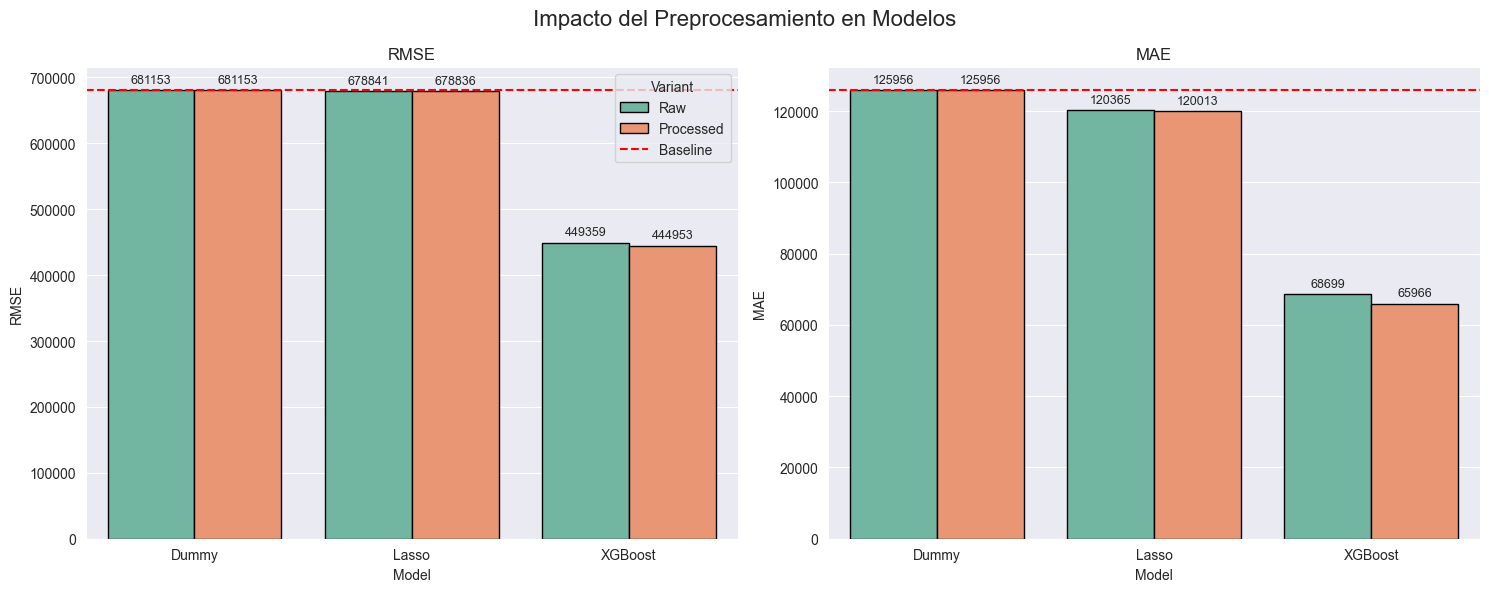

In [54]:
def feature_engineer(df_in):
    df_in = add_room_density(df_in)
    df_in = add_amenities_score(df_in)
    df_in = add_bath_bedroom_ratio(df_in)
    return df_in

plot_feature_engineering_impact(X_train, X_test, feature_engineer)

Tuvieron una pequeña mejora, sigamos probando:

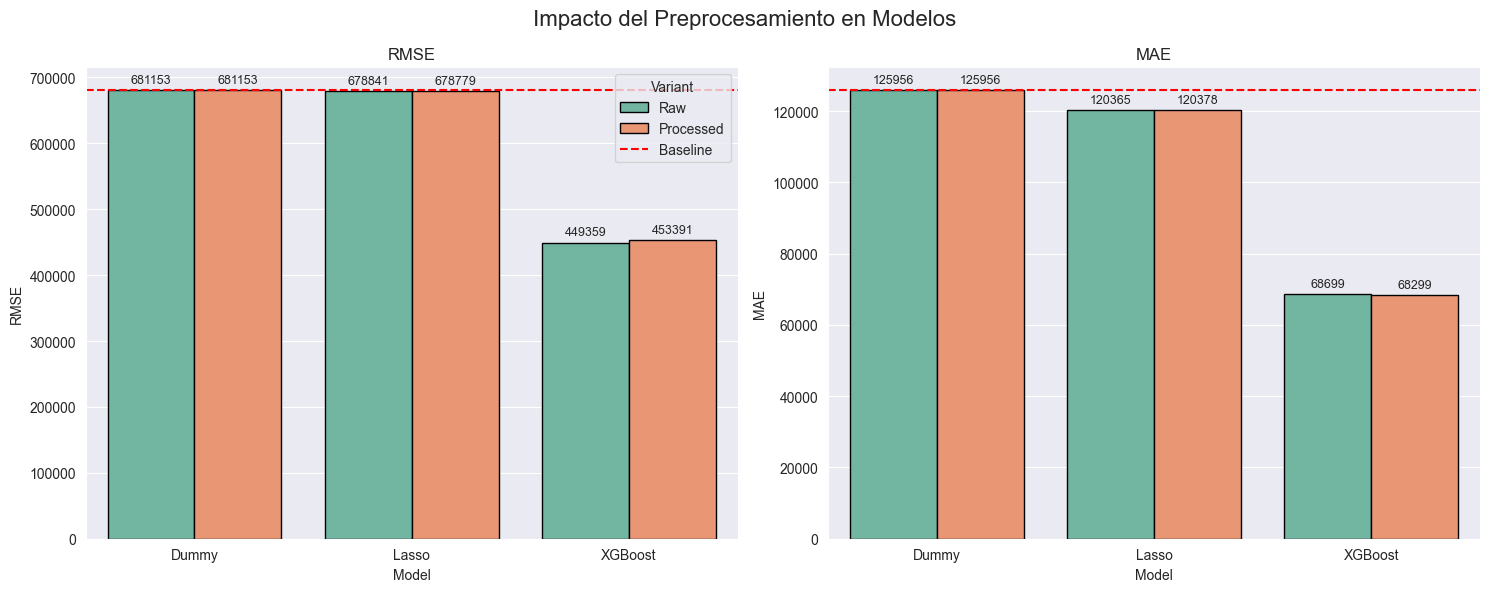

In [55]:
def add_geo_clusters(df_train, df_test, n_clusters=50):
    """
    Crea clusters geográficos basados en Latitud y Longitud.
    Retorna los DF con la nueva columna 'geo_cluster'.
    """
    # Copias para no tocar originales
    X_train_out = df_train.copy()
    X_test_out = df_test.copy()

    # Coordenadas
    coords_train = X_train_out[['LATITUDE', 'LONGITUDE']].fillna(0) # Ojo con nans

    # Entrenar KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(coords_train)

    # Predecir clusters
    X_train_out['geo_cluster'] = kmeans.predict(coords_train)

    # Para test usamos el kmeans ya entrenado (predict)
    coords_test = X_test_out[['LATITUDE', 'LONGITUDE']].fillna(0)
    X_test_out['geo_cluster'] = kmeans.predict(coords_test)

    return X_train_out, X_test_out
def add_distance_to_obelisk(df_in):
    """
    Calcula distancia euclidiana simple al Obelisco (aprox centro).
    Obelisco: -34.6037, -58.3816
    """
    df_out = df_in.copy()
    obelisk_lat = -34.6037
    obelisk_lon = -58.3816

    # Distancia Euclidiana (es una aproximación plana, para ranking sirve perfecto)
    # Multiplicamos por 100 aprox para que no queden números tan chicos (grados a km aprox)
    df_out['dist_obelisco'] = np.sqrt(
        (df_out['LATITUDE'] - obelisk_lat)**2 +
        (df_out['LONGITUDE'] - obelisk_lon)**2
    )
    return df_out

def feature_engineer2(df_in):
    add_distance_to_obelisk(df_in)
    return df_in

X_train_geo, X_test_geo = add_geo_clusters(X_train, X_test)

plot_feature_engineering_impact(X_train_geo, X_test_geo, feature_engineer2)

Estas empeoraron el RMSE y dejaron casi igual el MAE. Sigamos probando.

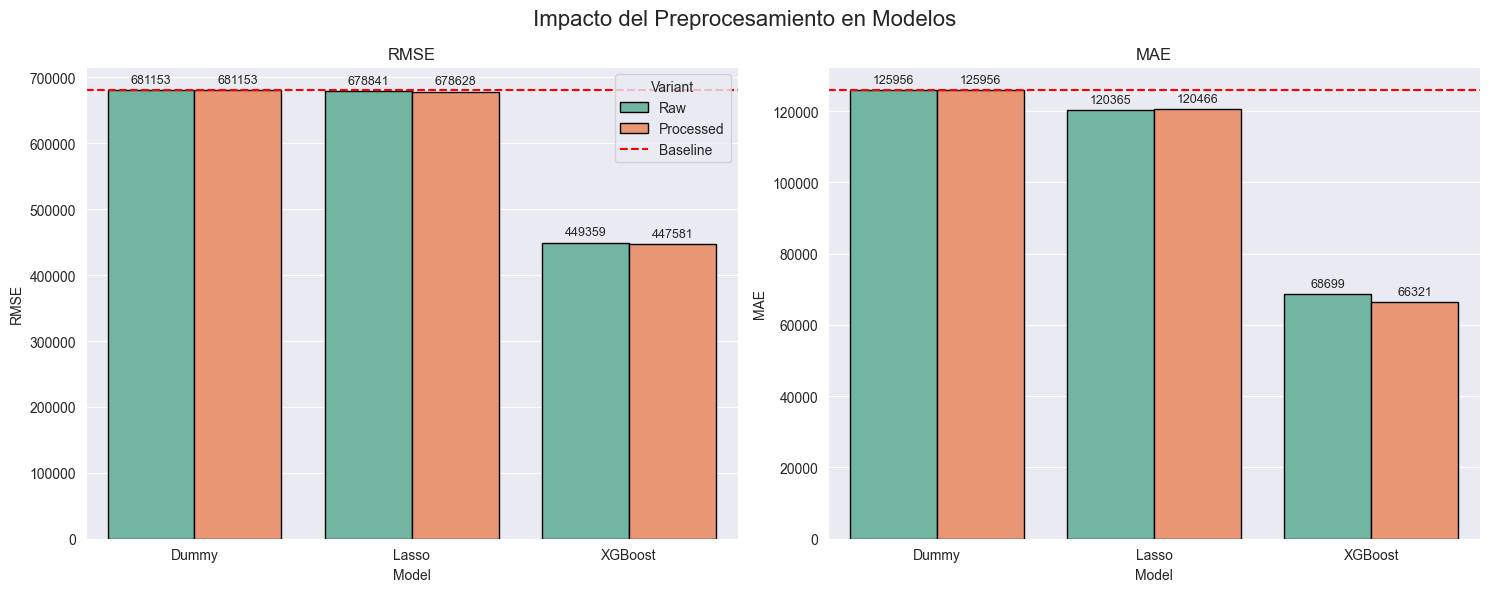

In [56]:
def add_uncovered_pct(df_in):
    df_out = df_in.copy()

    # Calculamos la diferencia primero (clipeada a 0)
    uncovered = (df_out['STotalM2'] - df_out['SConstrM2']).clip(lower=0)

    # Evitamos división por cero para seguridad
    total_safe = df_out['STotalM2'].replace(0, np.nan)

    # Calculamos ratio (0.0 a 1.0)
    df_out['pct_descubierto'] = uncovered / total_safe

    # Llenamos NaNs (si total era 0 o nulo) con 0
    df_out['pct_descubierto'] = df_out['pct_descubierto'].fillna(0)

    return df_out

plot_feature_engineering_impact(X_train, X_test, add_uncovered_pct)

Mejoró levemente el MAE! Sigamos probando:

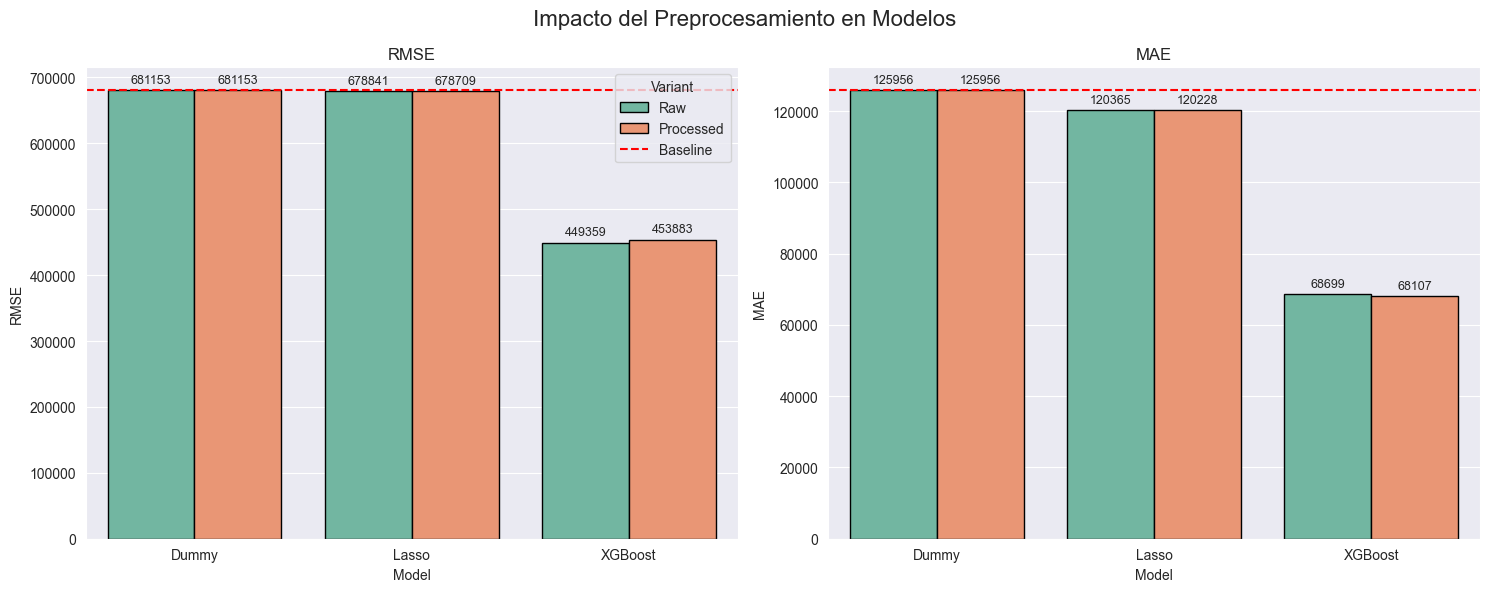

In [57]:
def add_barrio_target_encoding(X_train, y_train, X_test):
    # 1. Creamos un DF temporal de train con el target
    temp_train = X_train.copy()
    temp_train['target'] = y_train

    # 2. Calculamos precio por m2 real (evitando división por 0)
    # Usamos STotalM2 que suele ser la más completa
    temp_train['precio_m2_real'] = temp_train['target'] / temp_train['STotalM2'].replace(0, 1)

    # 3. Calculamos el promedio por Barrio
    # Agrupamos por barrio y sacamos la media del m2
    mapa_precios = temp_train.groupby('ITE_ADD_NEIGHBORHOOD_NAME')['precio_m2_real'].mean()

    # 4. Mapeamos a Train y Test
    # Si un barrio de Test no estaba en Train, rellenamos con el promedio global
    mean_global = temp_train['precio_m2_real'].mean()

    X_train_out = X_train.copy()
    X_test_out = X_test.copy()

    col_name = 'barrio_precio_m2_mean'
    X_train_out[col_name] = X_train_out['ITE_ADD_NEIGHBORHOOD_NAME'].map(mapa_precios).fillna(mean_global)
    X_test_out[col_name] = X_test_out['ITE_ADD_NEIGHBORHOOD_NAME'].map(mapa_precios).fillna(mean_global)

    return X_train_out, X_test_out

X_train_target, X_test_target = add_barrio_target_encoding(X_train, y_train, X_test)
def nothing_func(df_in):
    return df_in

plot_feature_engineering_impact(X_train_target, X_test_target, nothing_func)

/Users/gonza/Documents/Gonza/UdeSA/05-machine-learning/alquileres/venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.884e+16, tolerance: 9.849e+12
  model = cd_fast.enet_coordinate_descent(


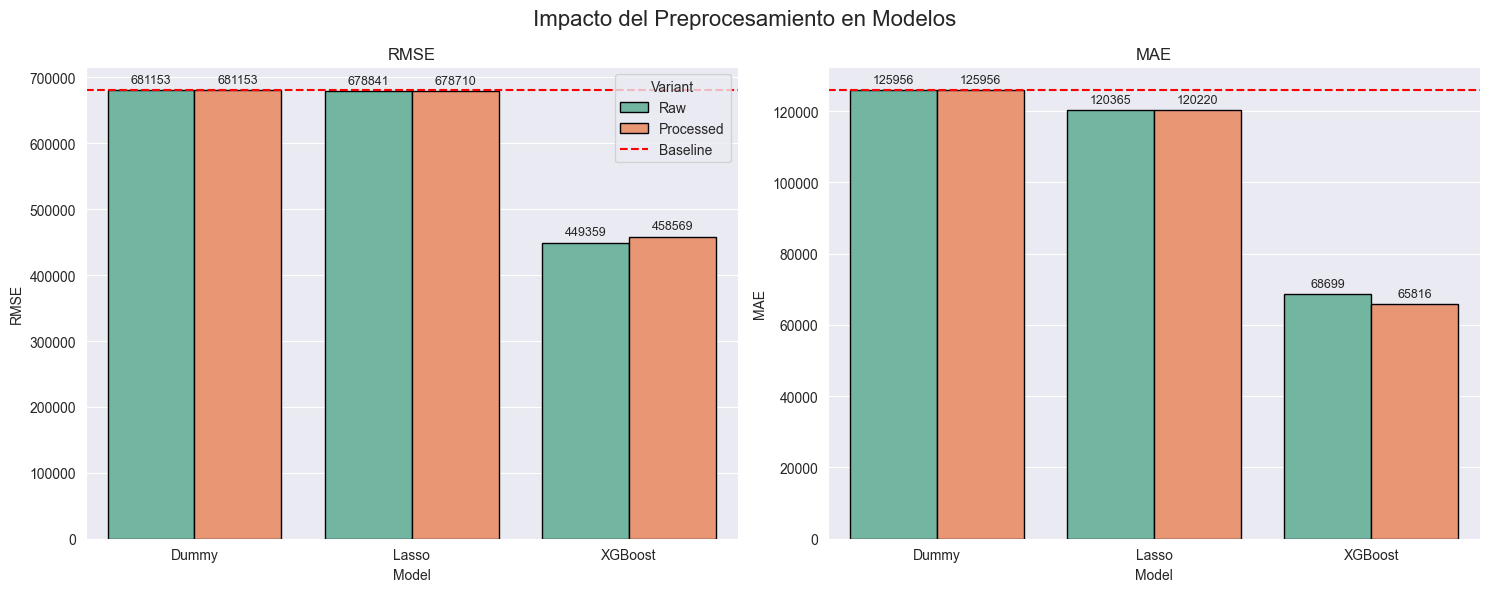

In [58]:
def add_m2_valorizados(df_in):
    """
    Crea la feature 'm2_valorizados' (Precio Base Teórico).
    Requiere que 'barrio_precio_m2_mean' exista en el DF.
    """
    df_out = df_in.copy()

    # Verificamos que exista el target encoding previo
    if 'barrio_precio_m2_mean' not in df_out.columns:
        raise ValueError("Primero debes correr 'add_barrio_target_encoding'")

    # Multiplicamos Superficie * Precio Promedio del Barrio
    df_out['m2_valorizados'] = df_out['STotalM2'] * df_out['barrio_precio_m2_mean']

    return df_out


plot_feature_engineering_impact(X_train_target, X_test_target, add_m2_valorizados)

Esta feature mejoró el MAE pero empeoró el RMSE

In [59]:
df.nlargest(50, TARGET)

,id_grid,STotalM2,SConstrM2,Dormitorios,Banos,Ambientes,Amoblado,Antiguedad,BusinessCenter,Gimnasio,...,ITE_ADD_CITY_NAME,ITE_ADD_STATE_NAME,ITE_ADD_NEIGHBORHOOD_NAME,ITE_TIPO_PROD,LONGITUDE,LATITUDE,precio_pesos_constantes,year,SUM,mes_listing
133453,64041,200.0,180.0,3.0,3.0,4.0,False,30.0,False,False,...,Capital Federal,Capital Federal,Palermo,U,-58.406546,-34.575996,3.518759e+07,2021,False,11
130696,64041,200.0,180.0,3.0,3.0,4.0,False,30.0,False,False,...,Capital Federal,Capital Federal,Palermo,U,-58.406546,-34.575996,3.495811e+07,2021,False,7
17039,64041,200.0,180.0,3.0,3.0,4.0,False,30.0,False,False,...,Capital Federal,Capital Federal,Palermo,U,-58.406546,-34.575996,3.457741e+07,2021,False,8
68036,64041,200.0,180.0,3.0,3.0,4.0,False,30.0,False,False,...,Capital Federal,Capital Federal,Palermo,U,-58.406546,-34.575996,3.453620e+07,2022,False,1
191511,64041,200.0,180.0,3.0,3.0,4.0,False,30.0,False,False,...,Capital Federal,Capital Federal,Palermo,U,-58.406546,-34.575996,3.424707e+07,2021,False,9
158792,64041,200.0,180.0,3.0,3.0,4.0,False,30.0,False,False,...,Capital Federal,Capital Federal,Palermo,U,-58.406546,-34.575996,3.401032e+07,2021,False,10
145472,64041,200.0,180.0,3.0,3.0,4.0,False,30.0,False,False,...,Capital Federal,Capital Federal,Palermo,U,-58.406546,-34.575996,3.389531e+07,2021,False,12
29521,65666,185.0,160.0,2.0,3.0,3.0,False,0.0,False,True,...,Capital Federal,Capital Federal,Belgrano,U,-58.449987,-34.566471,3.340594e+07,2021,False,11
185779,64041,200.0,180.0,3.0,3.0,4.0,False,30.0,False,False,...,Capital Federal,Capital Federal,Palermo,U,-58.406546,-34.575996,3.324498e+07,2022,False,2
7834,65666,185.0,160.0,2.0,3.0,3.0,False,0.0,False,True,...,Capital Federal,Capital Federal,Belgrano,U,-58.449987,-34.566471,3.318808e+07,2021,False,7


Las propiedades extremadamente caras parecieran estar en ID grids parecidos. Probemos hacer target encodign del ID grid:

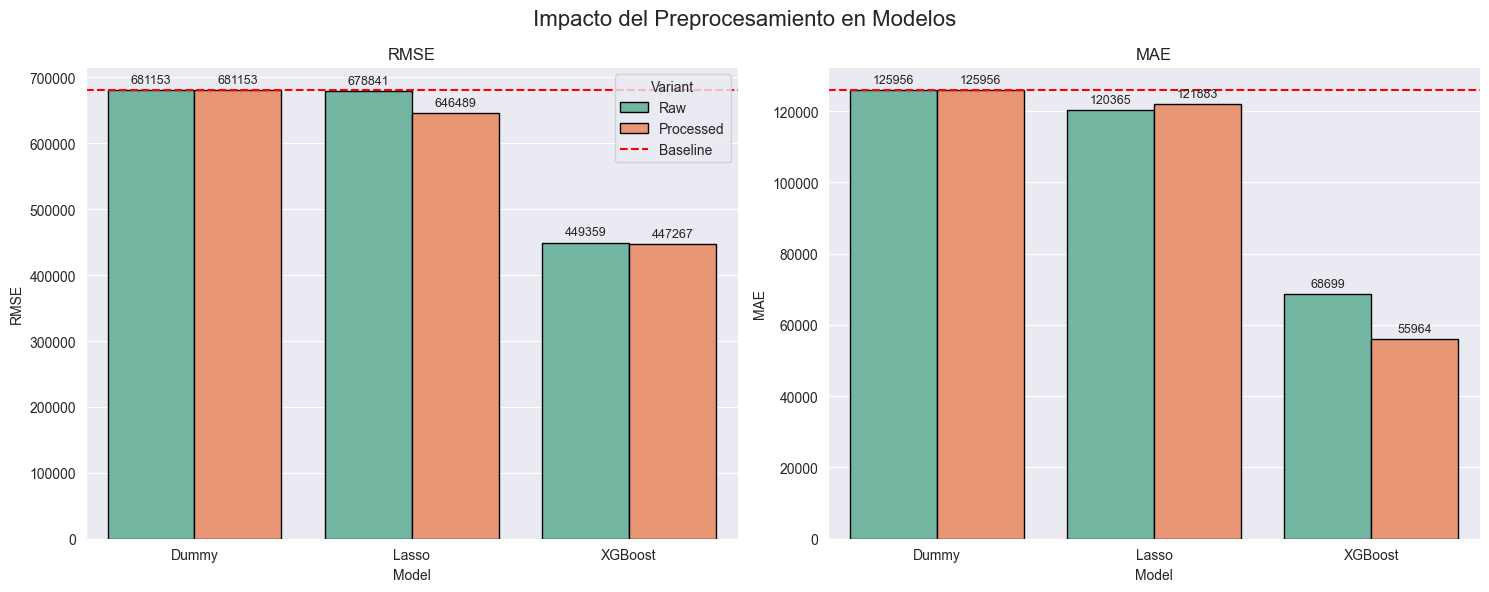

In [60]:
def add_id_grid_target_encoding(X_train, y_train, X_test, m=10):
    """
    Target Encoding de id_grid con suavizado (m-estimate).
    Valor = (count * mean_grid + m * global_mean) / (count + m)
    """
    # 1. Preparar datos
    X_train_out = X_train.copy()
    X_test_out = X_test.copy()

    # Check si id_grid existe (si la droppeaste antes, esto fallará)
    if 'id_grid' not in X_train_out.columns:
        print("¡Advertencia! 'id_grid' no encontrada. Verifica si no fue droppeada.")
        return X_train, X_test
    temp = X_train_out[['id_grid']].copy()
    temp['target'] = y_train

    # 2. Estadísticas globales
    global_mean = y_train.mean()

    # 3. Estadísticas por Grid
    grid_stats = temp.groupby('id_grid')['target'].agg(['sum', 'count'])

    # 4. Fórmula de Suavizado
    # Esto evita que si hay 1 sola casa que se vendió carísima, el grid quede marcado para siempre como "lujo".
    # 'm' es el peso del "prior" (promedio global). Cuanto más grande m, más conservador.
    grid_stats['smoothed_price'] = (grid_stats['sum'] + m * global_mean) / (grid_stats['count'] + m)

    mapping = grid_stats['smoothed_price'].to_dict()

    # 5. Mapear
    X_train_out['grid_price_mean'] = X_train_out['id_grid'].map(mapping).fillna(global_mean)
    X_test_out['grid_price_mean'] = X_test_out['id_grid'].map(mapping).fillna(global_mean) # Si grid nuevo en test, usa global

    return X_train_out, X_test_out

X_train_id, X_test_id = add_id_grid_target_encoding(X_train_target, y_train, X_test_target)
plot_feature_engineering_impact(X_train_id, X_test_id, nothing_func)

Mejoró mucho el MAE! Aunque el RMSE sigue igual

Probemos ahora cómo funciona nuestro modelo con las 5 features que funcionaron:

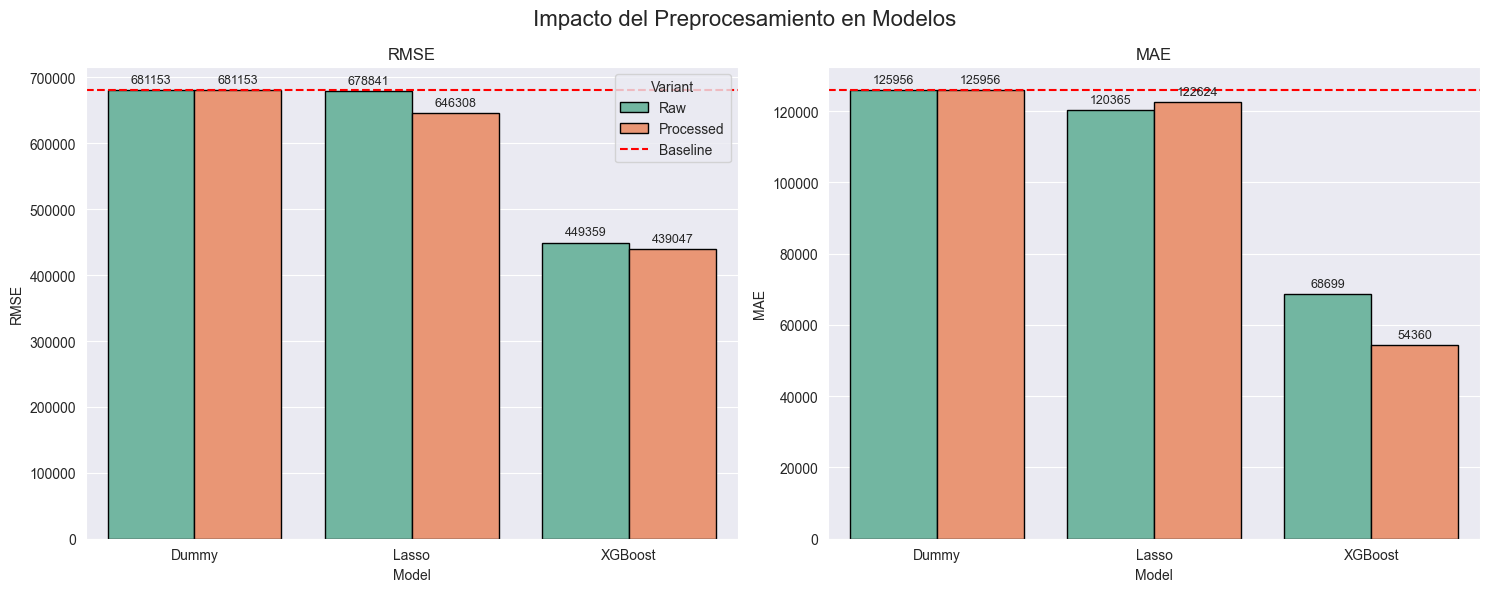

In [63]:
def engineer_features(df_in):
    df_in = add_amenities_score(df_in)
    df_in = add_room_density(df_in)
    df_in = add_bath_bedroom_ratio(df_in)
    df_in = add_uncovered_pct(df_in)
    # df_in = add_m2_valorizados(df_in)
    return df_in

# Usamos X_train_id para usar los target encoding sque hicimos
plot_feature_engineering_impact(X_train_id, X_test_id, engineer_features)

Luego de toda la feature engineering, la performance aumenta levemente para el RMSE, y muy considerablemente para el MAE. Entonces, vamos a aplicar las que funcionaron:

- Agregar score de amenities (suma de todos los amenities)
- Agregar tamaño promedio de cada ambiente (m2 / ambientes)
- Ratio entre dormitorios y baños
- Target encoding del barrio
- Porcentaje de la superficie descubierta
- M2 por el target encoding del barrio
- Target encoding del ID_grid

Todo esto será implementado en el FeatureCreator de preprocessing.py

In [64]:
conteo_grids = X_train['id_grid'].value_counts()
print("Cantidad de propiedades por grid (Top 5):")
print(conteo_grids.head())
print("\nCantidad de propiedades por grid (Last 5):")
print(conteo_grids.tail())
print(f"\nGrid con MENOS propiedades: {conteo_grids.idxmin()} ({conteo_grids.min()} propiedades)")
print(f"Número total de Grids únicos: {len(conteo_grids)}")
print(f"Grids con 1 sola propiedad: {(conteo_grids == 1).sum()}")

Cantidad de propiedades por grid (Top 5):
id_grid
57811    1080
56495     762
64034     748
96171     713
57482     672
Name: count, dtype: int64

Cantidad de propiedades por grid (Last 5):
id_grid
43889    1
44199    1
34445    1
81305    1
71544    1
Name: count, dtype: int64

Grid con MENOS propiedades: 40698 (1 propiedades)
Número total de Grids únicos: 12768
Grids con 1 sola propiedad: 2286
